# 📡 TelecomX LATAM — Análisis de Evasión de Clientes (Churn)

> **Objetivo:** Identificar los factores que llevan a la cancelación del servicio por parte de los clientes de TelecomX, con el fin de proponer estrategias de retención basadas en datos.

---

# 📌 Fase 1 — Extracción

En esta fase se cargan los datos directamente desde la API pública de GitHub y se convierten en un DataFrame de Pandas para facilitar su manipulación.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


In [2]:
# Carga de datos
URL = (
    'https://raw.githubusercontent.com/ingridcristh/'
    'challenge2-data-science-LATAM/main/TelecomX_Data.json'
)

response = requests.get(URL)
response.raise_for_status()

data_raw = response.json()
print(f'Datos descargados correctamente. Registros recibidos: {len(data_raw):,}')

Datos descargados correctamente. Registros recibidos: 7,267


In [3]:
# Conversión a DataFrame
df_raw = pd.json_normalize(data_raw)

print(f'Dimensiones del DataFrame: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df_raw.head()

Dimensiones del DataFrame: 7,267 filas × 21 columnas

Primeras 5 filas:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 Fase 2 — Transformación

En esta fase se exploran, limpian y transforman los datos para asegurar su calidad antes del análisis.

In [4]:
# Exploración inicial
print('TIPOS DE DATOS')
print(df_raw.dtypes)
print(f'\nDIMENSIONES: {df_raw.shape}')

TIPOS DE DATOS
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

DIMENSIONES: (7267, 21)


In [5]:
# Identificación de problemas en los datos

# Valores nulos
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)
resumen_nulos = pd.DataFrame({'Valores nulos': nulos, '% del total': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Valores nulos'] > 0]

print('VALORES NULOS')
print(resumen_nulos if not resumen_nulos.empty else 'Sin valores nulos detectados.')

# Duplicados
n_dup = df_raw.duplicated().sum()
print(f'\nFILAS DUPLICADAS: {n_dup}')

# Resumen estadístico
print('\nESTADÍSTICAS DESCRIPTIVAS')
df_raw.describe(include='all')

VALORES NULOS
Sin valores nulos detectados.

FILAS DUPLICADAS: 0

ESTADÍSTICAS DESCRIPTIVAS


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,3,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN


In [6]:
# Corrección de problemas
df = df_raw.copy()

# Eliminamos duplicados
df.drop_duplicates(inplace=True)
print(f'Filas tras eliminar duplicados: {len(df):,}')

# 2. Convertimos Charges.Total a numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')

# 3. Rellenamos Charges.Total nulo con 0
df['account.Charges.Total'].fillna(0, inplace=True)

# 4. Eliminamos filas donde Charges.Monthly sea nulo
antes = len(df)
df.dropna(subset=['account.Charges.Monthly'], inplace=True)
print(f'Filas eliminadas por Charges.Monthly nulo: {antes - len(df)}')

# 5. Normalizamos la columna Churn
df['Churn'] = df['Churn'].astype(str).str.strip()

print(f'\n DataFrame limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print('Valores únicos de Churn:', df['Churn'].unique())

Filas tras eliminar duplicados: 7,267
Filas eliminadas por Charges.Monthly nulo: 0

 DataFrame limpio: 7,267 filas × 21 columnas
Valores únicos de Churn: ['No' 'Yes' '']


In [7]:
# Creando una columna de Cuentas_Diarias
# Valor diario = facturación mensual / 30 días
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(4)

df[['customerID', 'account.Charges.Monthly', 'Cuentas_Diarias']].head()

,customerID,account.Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.1867
1,0003-MKNFE,59.9,1.9967
2,0004-TLHLJ,73.9,2.4633
3,0011-IGKFF,98.0,3.2667
4,0013-EXCHZ,83.9,2.7967


In [8]:
cols_binarias = [
    'customer.Partner', 'customer.Dependents', 'phone.PhoneService',
    'account.PaperlessBilling', 'Churn'
]

mapa_bin = {'Yes': 1, 'No': 0, '1': 1, '0': 0, 'True': 1, 'False': 0}

for col in cols_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapa_bin).fillna(df[col])

if 'customer.SeniorCitizen' in df.columns:
    df['customer.SeniorCitizen'] = pd.to_numeric(df['customer.SeniorCitizen'], errors='coerce').fillna(0).astype(int)

renombrar = {
    'customerID'                : 'ID_Cliente',
    'Churn'                     : 'Evasion',
    'customer.gender'           : 'Genero',
    'customer.SeniorCitizen'    : 'AdultoMayor',
    'customer.Partner'          : 'Pareja',
    'customer.Dependents'       : 'Dependientes',
    'customer.tenure'           : 'Meses_Contrato',
    'phone.PhoneService'        : 'Servicio_Telefono',
    'phone.MultipleLines'       : 'Multiples_Lineas',
    'internet.InternetService'  : 'Servicio_Internet',
    'internet.OnlineSecurity'   : 'Seguridad_Online',
    'internet.OnlineBackup'     : 'Backup_Online',
    'internet.DeviceProtection' : 'Proteccion_Dispositivo',
    'internet.TechSupport'      : 'Soporte_Tecnico',
    'internet.StreamingTV'      : 'Streaming_TV',
    'internet.StreamingMovies'  : 'Streaming_Peliculas',
    'account.Contract'          : 'Tipo_Contrato',
    'account.PaperlessBilling'  : 'Factura_Digital',
    'account.PaymentMethod'     : 'Metodo_Pago',
    'account.Charges.Monthly'   : 'Cargo_Mensual',
    'account.Charges.Total'     : 'Cargo_Total',
}

df.rename(columns=renombrar, inplace=True)

if 'Genero' in df.columns:
    df['Genero'] = df['Genero'].map({'Male': 'Masculino', 'Female': 'Femenino'}).fillna(df['Genero'])

print('Estandarización completada con éxito.')
print(df.columns.tolist()) # Verificamos los nuevos nombres

Estandarización completada con éxito.
['ID_Cliente', 'Evasion', 'Genero', 'AdultoMayor', 'Pareja', 'Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']


In [9]:
df.sample(7)

,ID_Cliente,Evasion,Genero,AdultoMayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
5892,8051-HJRLT,1.0,Femenino,1,0,0,1,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.55,70.55,2.3517
2860,3967-VQOGC,0.0,Femenino,0,1,1,67,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Mailed check,24.90,1680.25,0.8300
2433,3398-GCPMU,0.0,Femenino,1,1,1,72,1,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),89.55,6448.85,2.9850
713,1024-GUALD,1.0,Femenino,0,1,0,1,0,No phone service,DSL,No,No,No,No,No,No,Month-to-month,1,Electronic check,24.80,24.80,0.8267
2147,3005-NFMTA,1.0,Masculino,1,0,0,55,1,Yes,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,1,Electronic check,98.80,5617.75,3.2933
921,1302-UHBDD,0.0,Masculino,1,0,0,20,1,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,0,Electronic check,89.95,1648.45,2.9983
1689,2391-SOORI,1.0,Masculino,0,0,1,4,1,No,DSL,Yes,No,No,No,No,No,Month-to-month,0,Electronic check,49.35,219.65,1.6450


# 📊 Fase 3 — Carga y Análisis

Se realiza un análisis exploratorio completo para comprender la distribución de la evasión y los patrones asociados a distintas variables.

In [10]:
# Análisis descriptivo general
print('ESTADÍSTICAS DESCRIPTIVAS (variables numéricas)')
df.describe().T

ESTADÍSTICAS DESCRIPTIVAS (variables numéricas)


,count,mean,std,min,25%,50%,75%,max
AdultoMayor,7267.0,0.162653,0.369074,0.0000,0.00000,0.0000,0.00000,1.0000
Pareja,7267.0,0.484106,0.499782,0.0000,0.00000,0.0000,1.00000,1.0000
Dependientes,7267.0,0.300124,0.458343,0.0000,0.00000,0.0000,1.00000,1.0000
Meses_Contrato,7267.0,32.346498,24.571773,0.0000,9.00000,29.0000,55.00000,72.0000
Servicio_Telefono,7267.0,0.902711,0.296371,0.0000,1.00000,1.0000,1.00000,1.0000
Factura_Digital,7267.0,0.593230,0.491265,0.0000,0.00000,1.0000,1.00000,1.0000
Cargo_Mensual,7267.0,64.720098,30.129572,18.2500,35.42500,70.3000,89.87500,118.7500
Cargo_Total,7267.0,2277.182035,2268.648587,0.0000,396.20000,1389.2000,3778.52500,8684.8000
Cuentas_Diarias,7267.0,2.157337,1.004319,0.6083,1.18085,2.3433,2.99585,3.9583


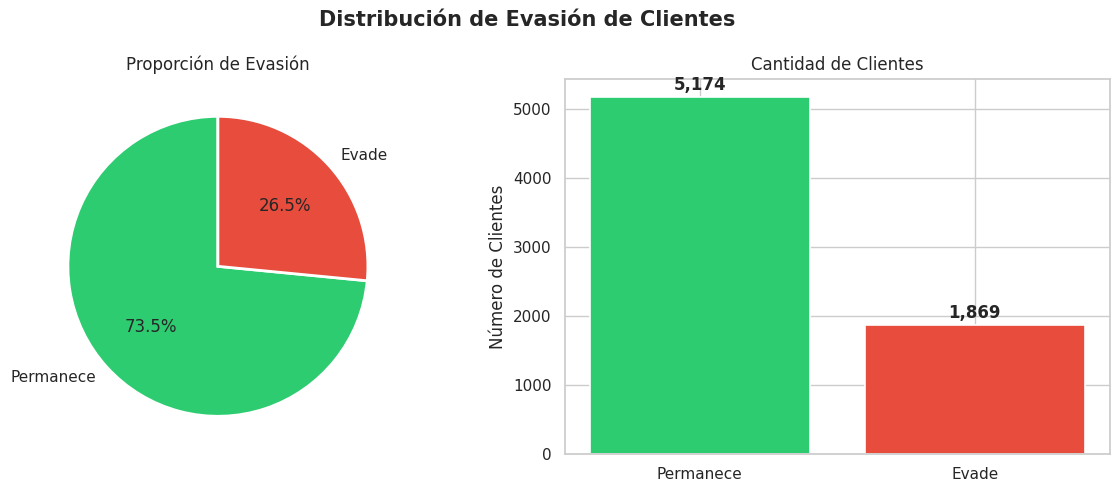

Tasa de evasión: 26.5%


In [11]:
# Distribución de evasión de clientes
conteo_evasion = df['Evasion'].value_counts().reindex([0,1], fill_value=0)

etiquetas = ['Permanece', 'Evade']
colores = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Evasión de Clientes', fontsize=15, fontweight='bold')

# Pastel
axes[0].pie(
    conteo_evasion,
    labels=etiquetas,
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[0].set_title('Proporción de Evasión')

# Barras
bars = axes[1].bar(etiquetas, conteo_evasion.values, color=colores, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, conteo_evasion.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

axes[1].set_title('Cantidad de Clientes')
axes[1].set_ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

tasa_evasion = conteo_evasion[1] / conteo_evasion.sum() * 100
print(f'Tasa de evasión: {tasa_evasion:.1f}%')

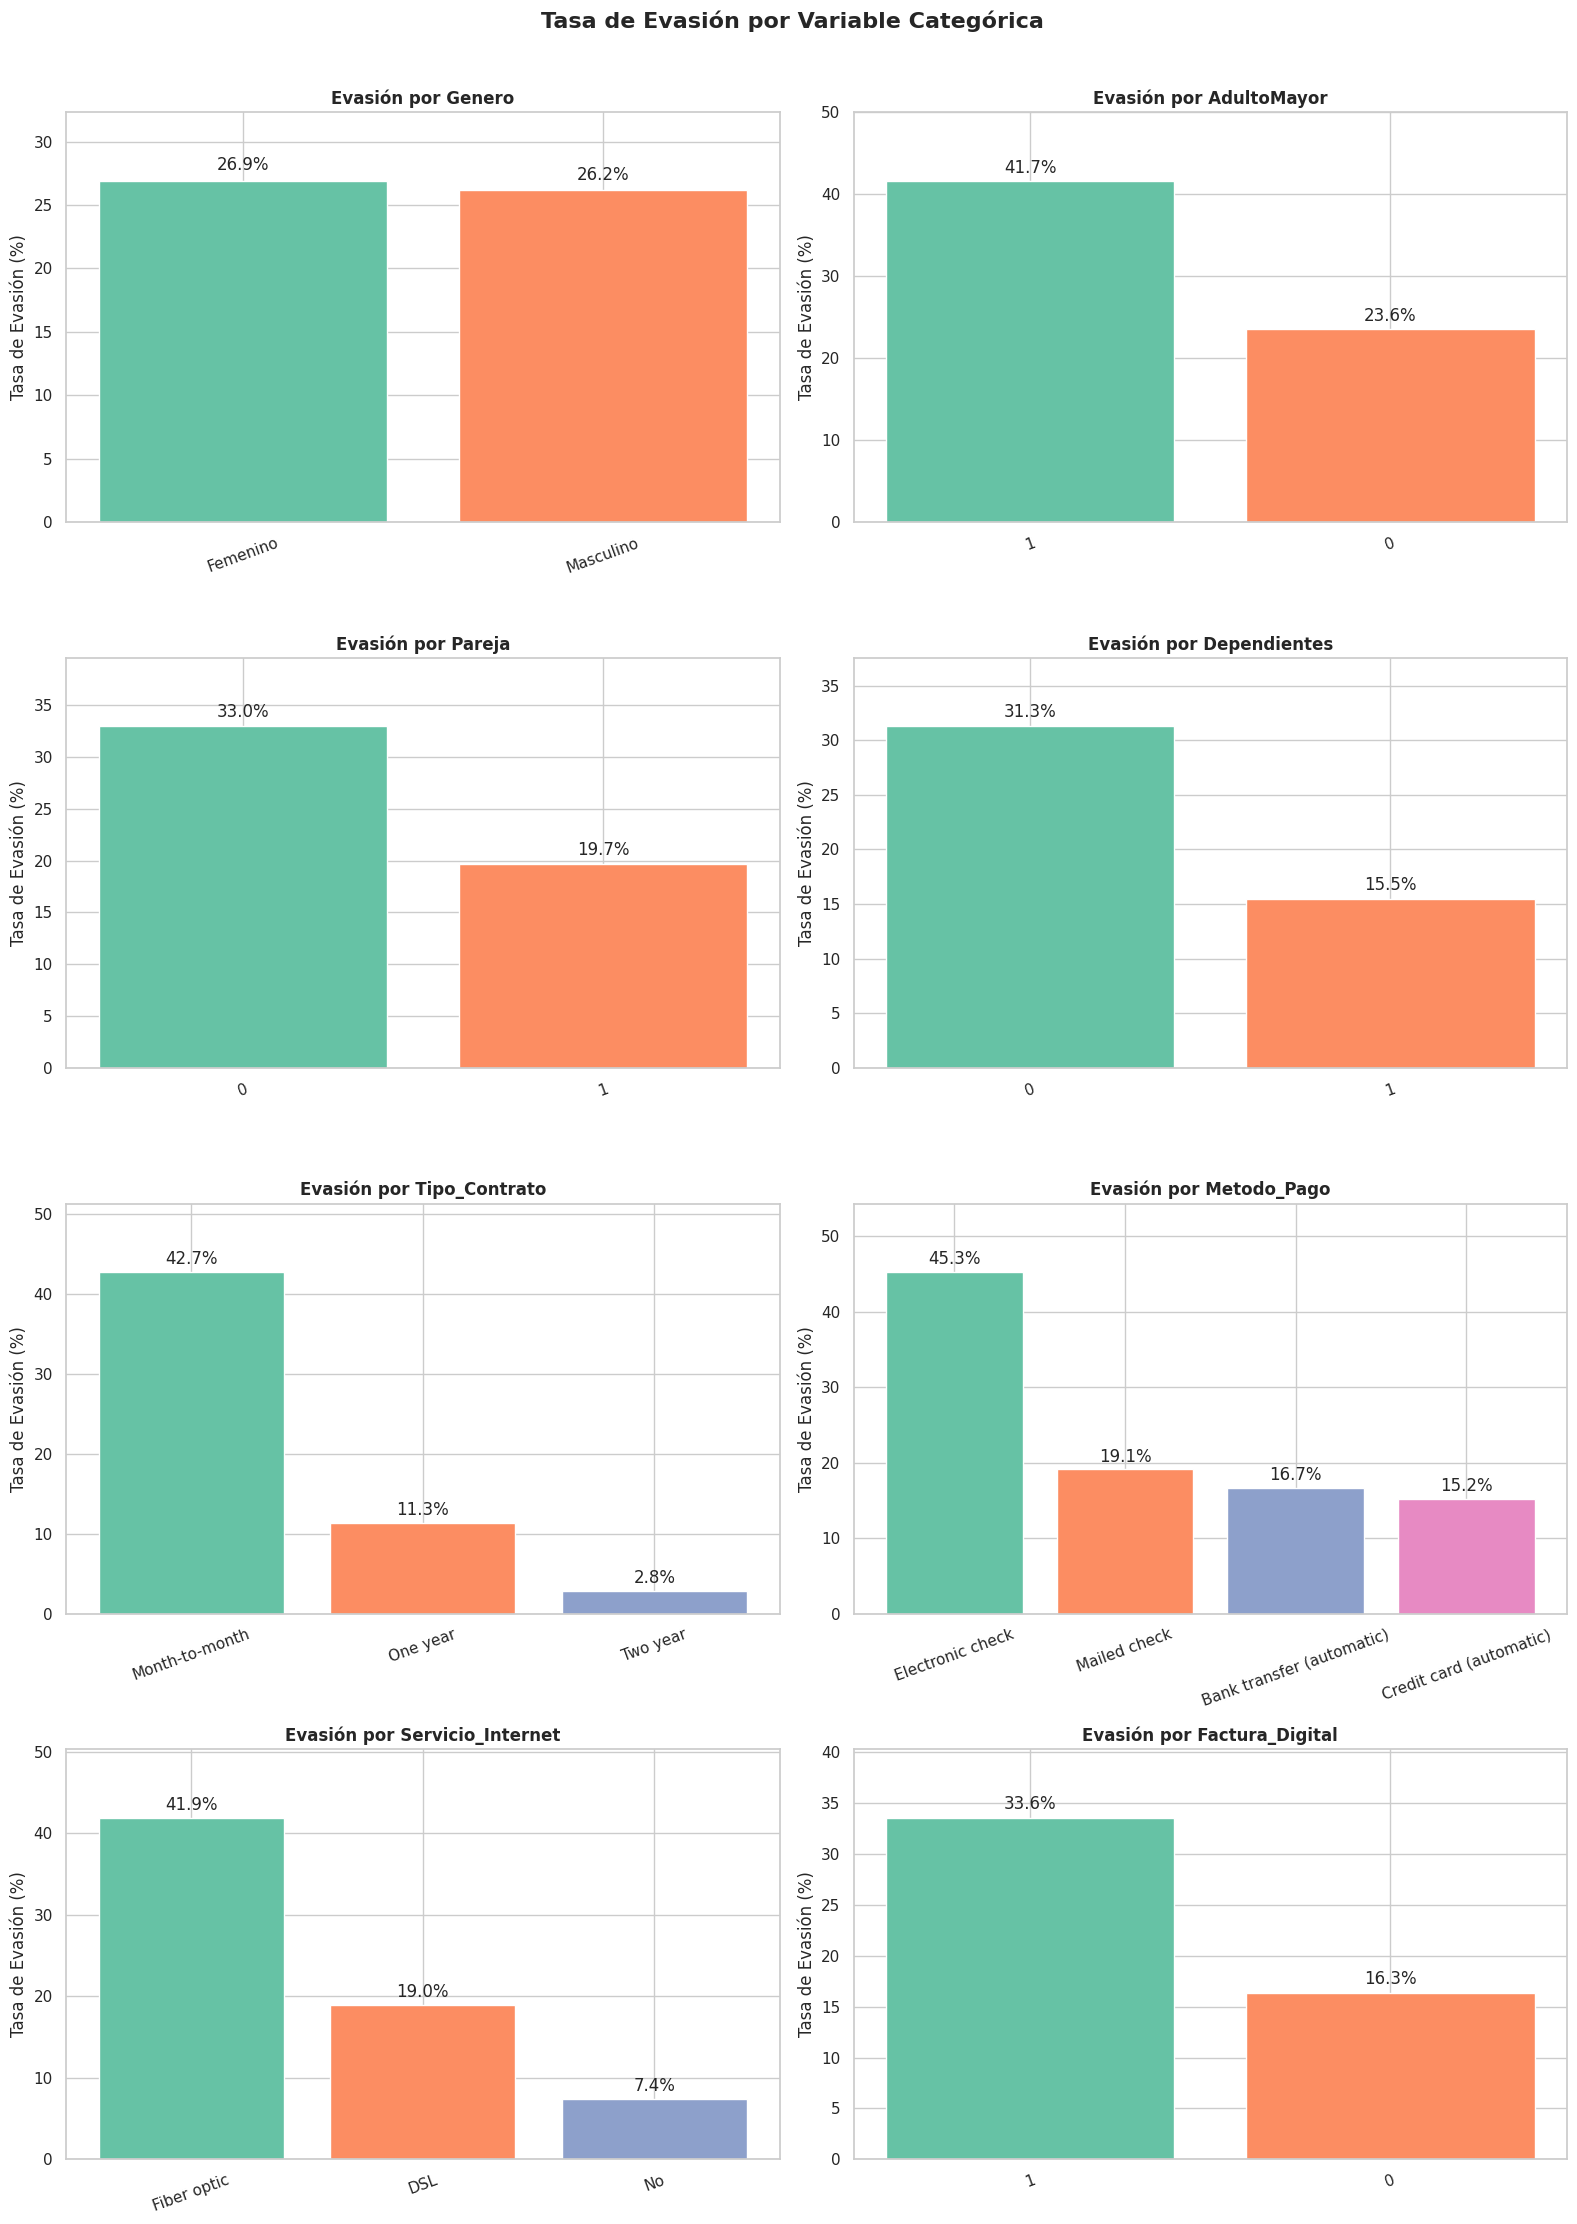

In [12]:
# Evasión por variables categóricas
df['Evasion'] = pd.to_numeric(df['Evasion'], errors='coerce')

df = df.dropna(subset=['Evasion'])

categoricas = [
    'Genero', 'AdultoMayor', 'Pareja', 'Dependientes',
    'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet',
    'Factura_Digital'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

fig.suptitle('Tasa de Evasión por Variable Categórica', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(categoricas):

    tasa = df.groupby(col)['Evasion'].mean().sort_values(ascending=False) * 100

    bars = axes[i].bar(
        tasa.index.astype(str),
        tasa.values,
        color=sns.color_palette('Set2', len(tasa)),
        edgecolor='white'
    )

    for bar, val in zip(bars, tasa.values):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center',
            va='bottom'
        )

    axes[i].set_title(f'Evasión por {col}', fontweight='bold')
    axes[i].set_ylabel('Tasa de Evasión (%)')
    axes[i].set_ylim(0, tasa.max() * 1.2)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

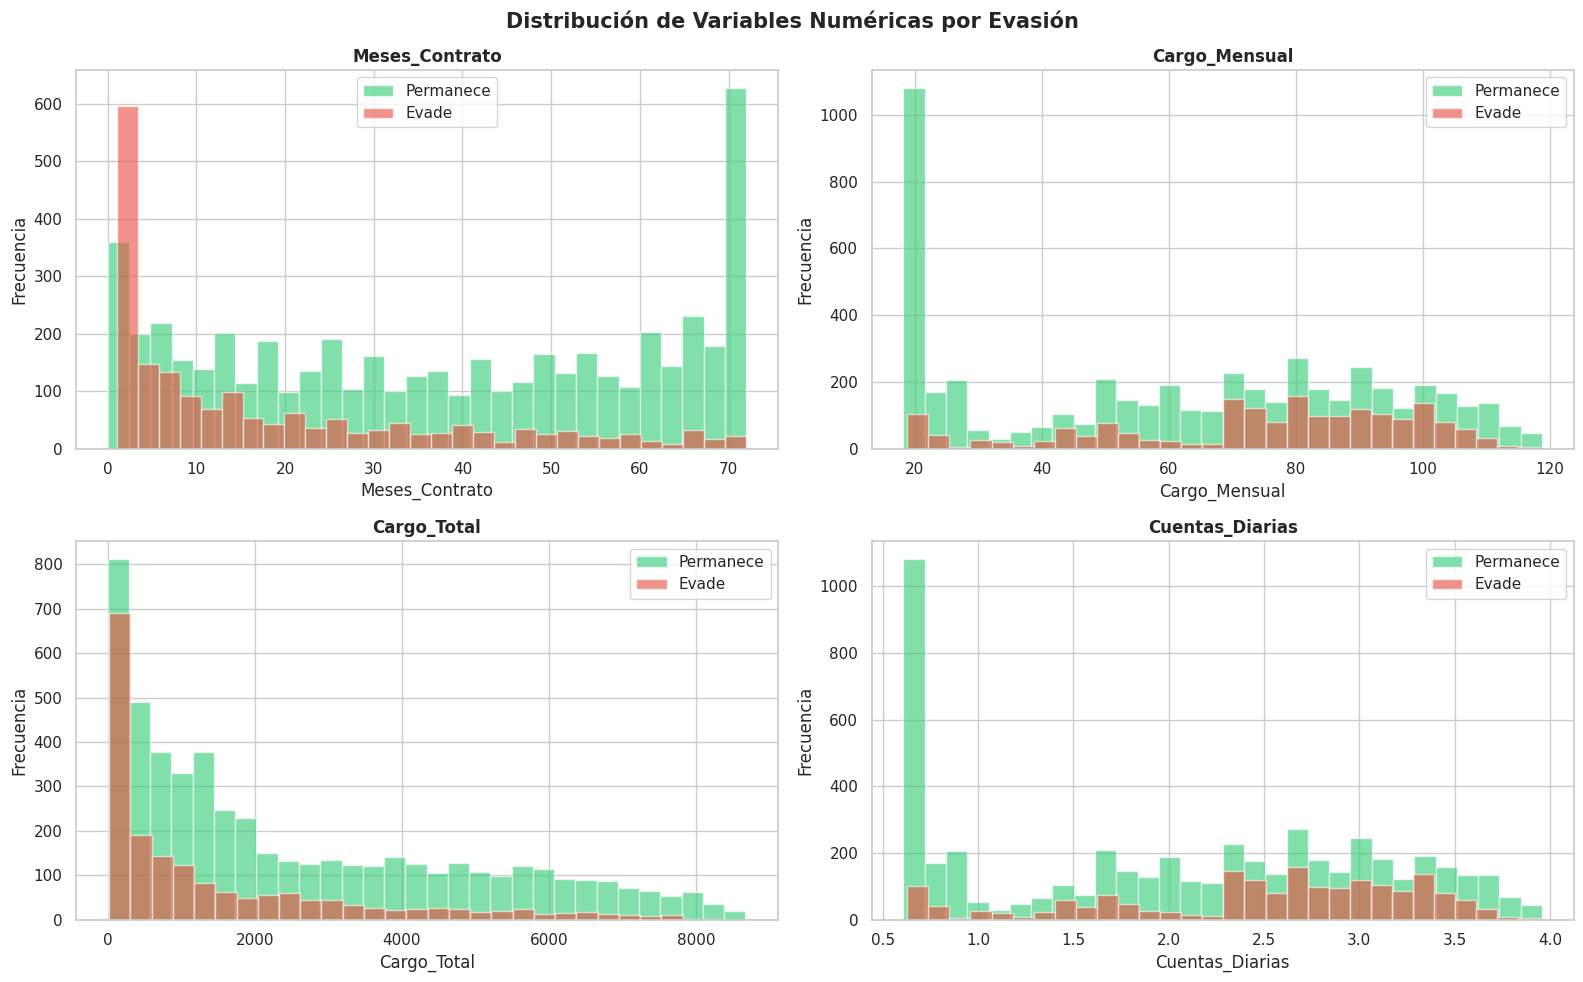

In [13]:
# Evasión por Variables Numéricas
numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Distribución de Variables Numéricas por Evasión', fontsize=15, fontweight='bold')

labels_evasion = {0: 'Permanece', 1: 'Evade'}
colores_ev = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(numericas):
    if col not in df.columns:
        continue
    for ev_val, label in labels_evasion.items():
        subset = df[df['Evasion'] == ev_val][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, label=label,
                     color=colores_ev[ev_val], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.tight_layout()
plt.show()

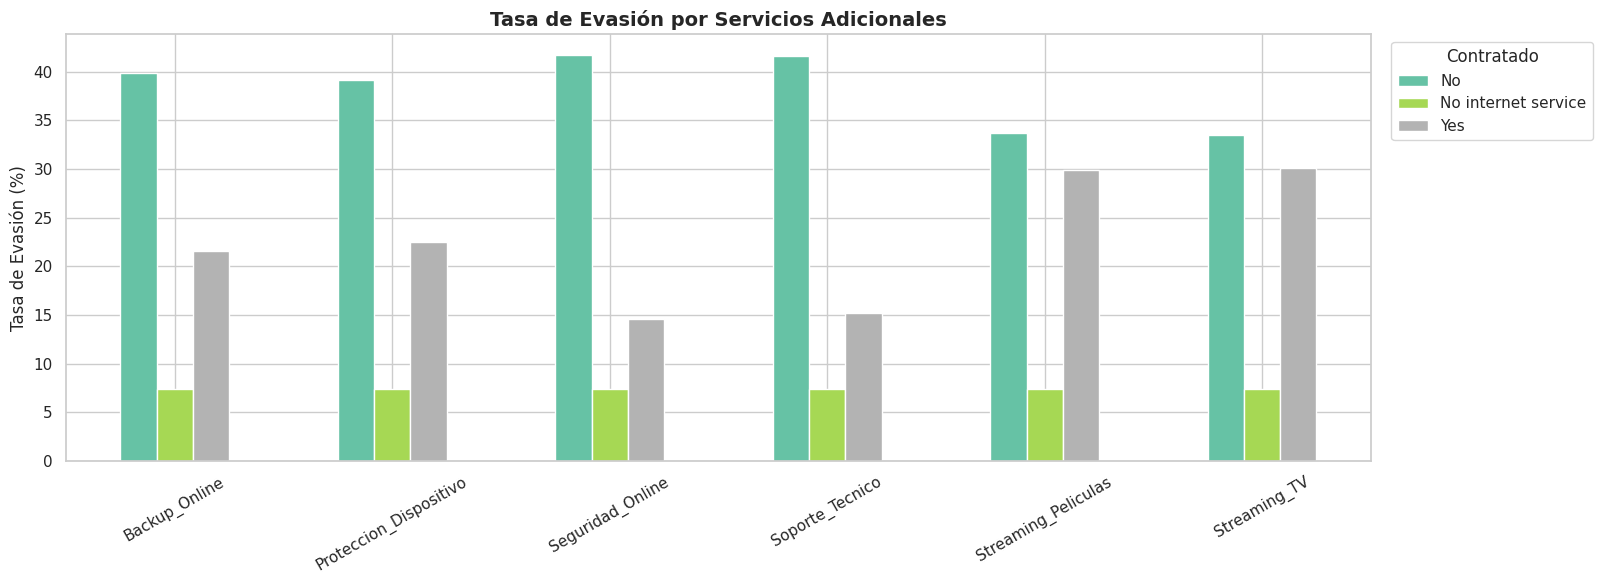

In [14]:
# Servicios adicionales vs. Evasión
servicios = [
    'Seguridad_Online', 'Backup_Online',
    'Proteccion_Dispositivo', 'Soporte_Tecnico',
    'Streaming_TV', 'Streaming_Peliculas'
]

# Calculando tasas de evasión para cada valor de cada servicio
resultados = []
for svc in servicios:
    if svc not in df.columns:
        continue
    for val in df[svc].dropna().unique():
        tasa = df[df[svc] == val]['Evasion'].mean() * 100
        resultados.append({'Servicio': svc, 'Valor': str(val), 'Tasa_Evasion': tasa})

df_svc = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(14, 6))
pivot = df_svc.pivot(index='Servicio', columns='Valor', values='Tasa_Evasion')
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Tasa de Evasión por Servicios Adicionales', fontsize=14, fontweight='bold')
ax.set_ylabel('Tasa de Evasión (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Contratado', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

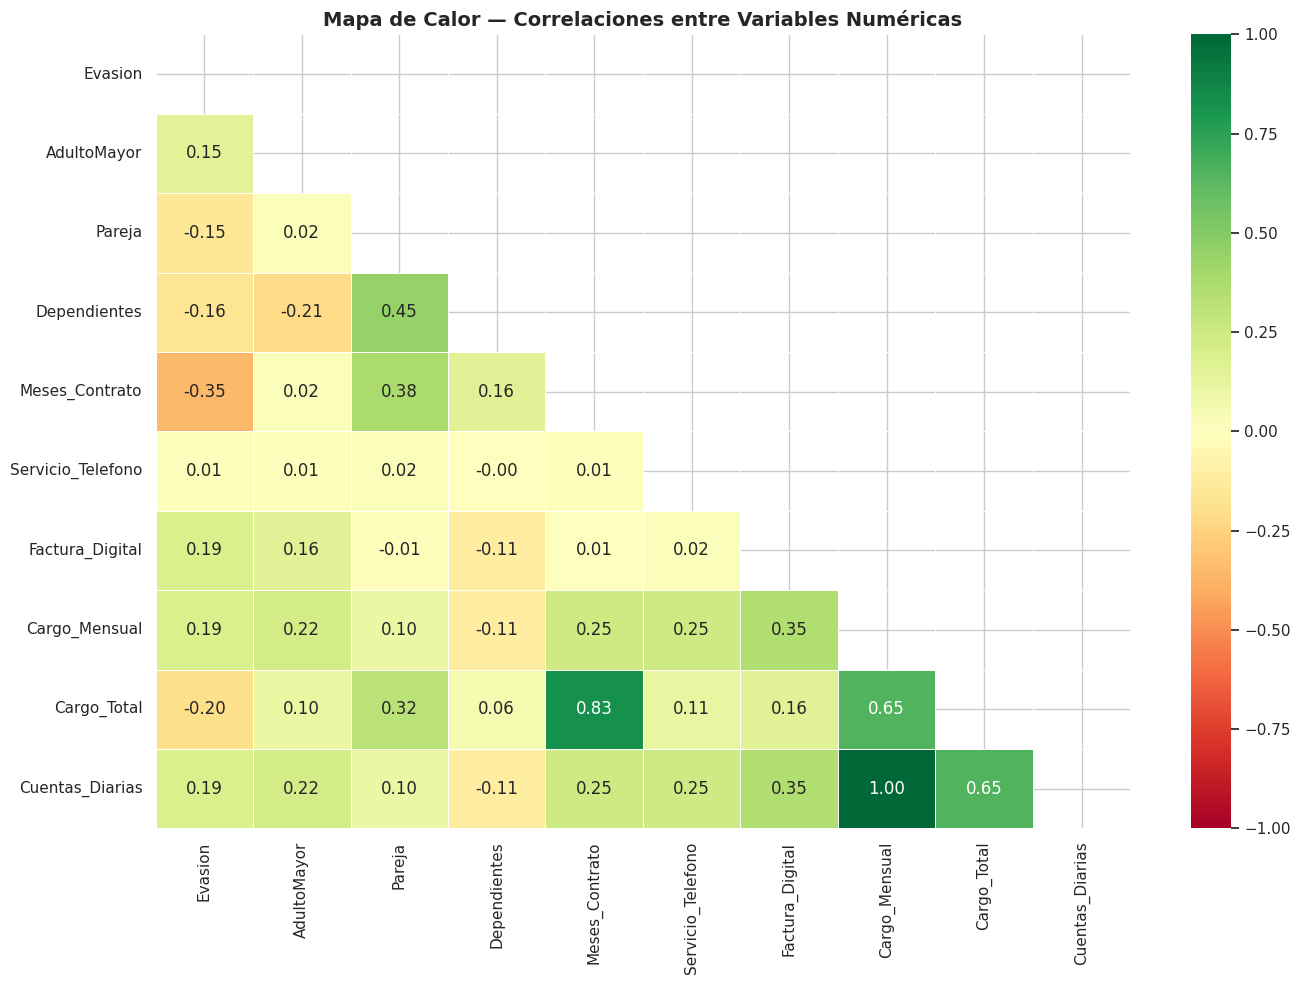

In [15]:
# Mapa de calor de correlaciones
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Mapa de Calor — Correlaciones entre Variables Numéricas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

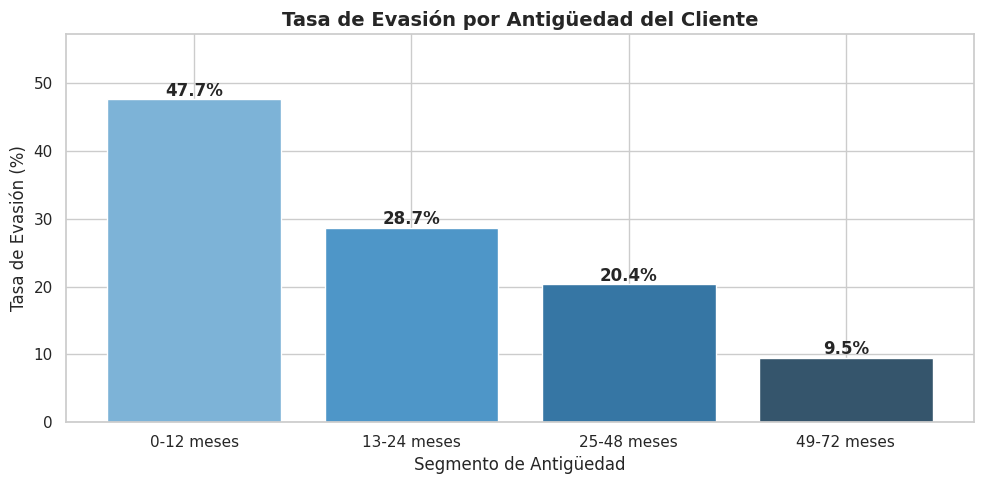

In [16]:
# Evasión según tenure (antigüedad)
df['Segmento_Antiguedad'] = pd.cut(
    df['Meses_Contrato'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 meses', '13-24 meses', '25-48 meses', '49-72 meses']
)

tasa_antiguedad = df.groupby('Segmento_Antiguedad')['Evasion'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    tasa_antiguedad.index.astype(str),
    tasa_antiguedad.values,
    color=sns.color_palette('Blues_d', len(tasa_antiguedad)),
    edgecolor='white'
)
for bar, val in zip(bars, tasa_antiguedad.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Tasa de Evasión por Antigüedad del Cliente', fontsize=14, fontweight='bold')
ax.set_xlabel('Segmento de Antigüedad')
ax.set_ylabel('Tasa de Evasión (%)')
ax.set_ylim(0, tasa_antiguedad.max() * 1.2)
plt.tight_layout()
plt.show()

# 📄 Fase 4 — Informe Final

---

## 🔹 Introducción

TelecomX LATAM enfrenta una problemática crítica: una alta tasa de cancelaciones (churn). La pérdida de clientes no solo representa ingresos no generados, sino también costos de adquisición de nuevos usuarios. Este análisis tiene como objetivo identificar los patrones y factores que predicen la evasión, para orientar estrategias de retención basadas en evidencia.

---

## Limpieza y Tratamiento de Datos

El proceso de preparación de datos incluyó las siguientes etapas:

**Extracción**: Los datos fueron cargados directamente desde la API pública de GitHub en formato JSON y normalizados para gestionar columnas anidadas (como `Charges.Monthly` y `Charges.Total`).

**Eliminación de duplicados**: Se verificó y eliminaron registros duplicados para garantizar la unicidad de los clientes.

**Corrección de tipos de datos**: Las columnas de cargos (`Charges.Monthly`, `Charges.Total`) fueron convertidas explícitamente a tipo numérico, tratando strings vacíos como valores nulos.

**Imputación de nulos**: Los valores nulos en `Charges.Total` se reemplazaron con 0 (clientes sin historial de facturación), mientras que las filas con `Charges.Monthly` nulo fueron eliminadas por ser inútiles para el análisis.

**Nueva variable**: Se creó la columna `Cuentas_Diarias` (= Cargo Mensual / 30) para tener una granularidad diaria del costo.

**Estandarización**: Las variables binarias (Yes/No) se codificaron como 1/0. Las columnas y categorías fueron traducidas al español para mayor claridad.

---

## Análisis Exploratorio de Datos

Alerta Roja: Factores de Alto Riesgo
El "Mes a Mes" es el enemigo: Los contratos mensuales superan el 40% de fuga, mientras que los anuales tienen menos del 5%.

La barrera de los 12 meses: El primer año de vida del cliente es la zona de mayor peligro; si superan el año, la lealtad aumenta drásticamente.

Fibra Óptica bajo la lupa: Irónicamente, los clientes con fibra se van más que los de DSL. ¿Precio alto o mala estabilidad?

Factores de Retención (Anclas)
Servicios "Sticky": El Seguro Online, Soporte Técnico y Backup actúan como pegamento; los clientes que los tienen se quedan más tiempo.

Perfil Social: Los clientes con pareja y dependientes son más estables que los solteros o adultos mayores.

---

## Conclusiones e Insights

| Factor | Impacto en Evasión |
|---|---|
| Contrato mensual | 🔴 Muy alto |
| Poca antigüedad (< 12 meses) | 🔴 Muy alto |
| Sin servicios adicionales | 🟠 Alto |
| Internet Fiber Optic | 🟠 Alto |
| Cargo mensual elevado | 🟡 Moderado |
| Adulto mayor sin pareja | 🟡 Moderado |
| Facturación digital | 🟡 Moderado |

Los tres factores más determinantes de la evasión son: **el tipo de contrato (mensual vs. anual)**, **la antigüedad del cliente (primeros 12 meses)** y **la ausencia de servicios complementarios**.

---

## Recomendaciones Estratégicas

**Acción Inmediata: Migración Contractual**
Lanzar campaña de "Upgrade a Anual". Ofrecer 1 mes gratis o descuento en equipo a cambio de pasar de contrato mensual a 1 o 2 años.

**Onboarding "Guante Blanco"**
Implementar un protocolo de seguimiento intensivo durante los primeros 365 días. El foco debe estar en que el cliente nuevo use todas las herramientas contratadas.

**Bundling Preventivo**
Empaquetar la Seguridad Online y Soporte Técnico por defecto en los planes de Fibra Óptica para suavizar la percepción de precio y aumentar el valor del servicio.

**Próximo Paso Técnico: Modelo Predictivo**
Entrenar un modelo de Machine Learning (XGBoost o Random Forest) utilizando las variables identificadas para generar alertas automáticas cuando un cliente presente patrones de fuga.
---
**Conclusión General:** La clave de TelecomX no es solo bajar precios, sino "anclar" al cliente mediante contratos a largo plazo y servicios de valor agregado durante su primer año.

In [17]:
total_clientes = len(df)
evaden = df['Evasion'].sum()
permanecen = total_clientes - evaden
tasa = evaden / total_clientes * 100

print('=' * 50)
print('      TelecomX')
print('=' * 50)
print(f'  Total de clientes analizados : {total_clientes:,}')
print(f'  Clientes que permanecen      : {int(permanecen):,}')
print(f'  Clientes que evaden          : {int(evaden):,}')
print(f'  Tasa de evasión (Churn)      : {tasa:.1f}%')
print('=' * 50)
print('  Principales factores de riesgo:')
print('    1. Contrato mensual (Month-to-month)')
print('    2. Antigüedad menor a 12 meses')
print('    3. Sin servicios adicionales contratados')
print('    4. Servicio de internet Fiber Optic')
print('    5. Cargo mensual elevado')
print('=' * 50)

      TelecomX
  Total de clientes analizados : 7,043
  Clientes que permanecen      : 5,174
  Clientes que evaden          : 1,869
  Tasa de evasión (Churn)      : 26.5%
  Principales factores de riesgo:
    1. Contrato mensual (Month-to-month)
    2. Antigüedad menor a 12 meses
    3. Sin servicios adicionales contratados
    4. Servicio de internet Fiber Optic
    5. Cargo mensual elevado
